In [20]:
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from datetime import datetime
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_model import  ARIMA,ARIMAResults
from statsmodels.tsa.ar_model import AR,ARResults
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [36]:
df= pd.read_csv("covid19.csv",index_col='Date',parse_dates=['Date'],dayfirst=True)
df = df.dropna(axis='rows', how='all')
df.tail()

,S. No.,Region,Confirmed Cases,Daily Cases
Date,,,,
2021-05-09,416.0,India,22296414.0,403738.0
2021-05-10,417.0,India,22662575.0,366161.0
2021-05-11,418.0,India,22992517.0,329942.0
2021-05-12,419.0,India,23340938.0,348421.0
2021-05-13,420.0,India,23703665.0,362727.0


In [37]:
df=df.drop(["S. No.","Region","Confirmed Cases"],axis=1)
df = df.iloc[1:]
df=df.reset_index()


In [38]:
df=df.set_index("Date")

In [39]:
df.head()

,Daily Cases
Date,
2020-03-13,1.0
2020-03-14,9.0
2020-03-15,23.0
2020-03-16,7.0
2020-03-17,23.0


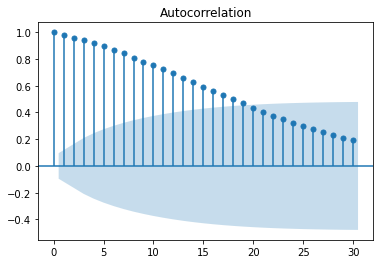

In [40]:
from statsmodels.tsa.stattools import acf,pacf
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
plot_acf(df['Daily Cases'].tolist(),lags=30)

plt.show()

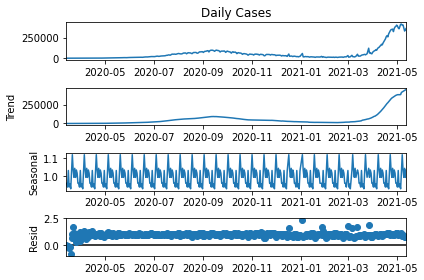

In [41]:
mul = seasonal_decompose(df['Daily Cases'], model='multiplicative',  extrapolate_trend='freq', freq=15)
mul.plot();

In [42]:
dftest = adfuller(df['Daily Cases'],autolag='AIC')
dfoutput = pd.Series(dftest[0:4], index=['Test Stat','p-value','#LAGS','Number of Observations'])
for key,value in dftest[4].items():
    dfoutput["CV (%s)"%key]= value
print(dfoutput)

Test Stat                  -4.759500
p-value                     0.000065
#LAGS                      15.000000
Number of Observations    403.000000
CV (1%)                    -3.446681
CV (5%)                    -2.868739
CV (10%)                   -2.570605
dtype: float64


In [43]:
arima_model =  auto_arima(df['Daily Cases'],start_p=0, d=1, start_q=0, 
                          max_p=5, max_d=5, max_q=5, start_P=0, 
                          D=1, start_Q=0, max_P=5, max_D=5,
                          max_Q=5, m=7, seasonal=True, 
                          error_action='warn',trace = True,
                           supress_warnings=True,stepwise = False,random=True,
                          random_state=42,n_fits = 20 )

 ARIMA(1,1,1)(0,1,2)[7]             : AIC=8564.878, Time=0.63 sec
 ARIMA(0,1,0)(4,1,1)[7]             : AIC=8596.111, Time=2.88 sec
 ARIMA(3,1,0)(2,1,0)[7]             : AIC=8588.049, Time=0.56 sec
 ARIMA(1,1,0)(2,1,2)[7]             : AIC=8565.517, Time=1.27 sec
 ARIMA(2,1,0)(0,1,3)[7]             : AIC=8563.963, Time=1.31 sec
 ARIMA(1,1,1)(1,1,2)[7]             : AIC=8565.227, Time=1.36 sec
 ARIMA(0,1,1)(2,1,1)[7]             : AIC=8567.066, Time=0.85 sec
 ARIMA(0,1,4)(0,1,1)[7]             : AIC=8576.978, Time=0.51 sec
 ARIMA(3,1,1)(0,1,0)[7]             : AIC=8635.288, Time=0.29 sec
 ARIMA(0,1,2)(2,1,1)[7]             : AIC=8565.780, Time=0.95 sec
 ARIMA(0,1,0)(0,1,4)[7]             : AIC=8621.442, Time=1.49 sec
 ARIMA(2,1,1)(1,1,0)[7]             : AIC=8595.579, Time=0.60 sec
 ARIMA(0,1,2)(0,1,0)[7]             : AIC=8631.290, Time=0.08 sec
 ARIMA(2,1,0)(1,1,2)[7]             : AIC=8564.956, Time=1.32 sec
 ARIMA(1,1,1)(2,1,0)[7]             : AIC=8586.855, Time=0.57 sec
 ARIMA(0,1

In [44]:
prediction = pd.DataFrame(arima_model.predict(n_periods = 20))
prediction.columns = ['predicted_Daily_infections']
prediction

,predicted_Daily_infections
0,369047.734173
1,368981.637034
2,370458.542278
3,350873.405546
4,329239.472055
5,346334.991214
6,361930.012403
7,368256.139193
8,370986.462142
9,373269.328330


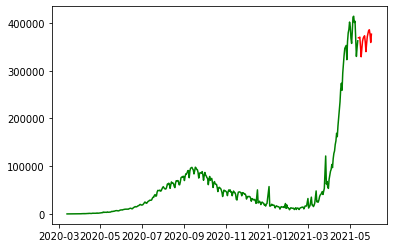

In [45]:
import datetime
dti = pd.date_range("2021-05-14", periods=20, freq="D")
dti
prediction.index = dti
plt.plot(df['Daily Cases'],color='g')
plt.plot(prediction['predicted_Daily_infections'],color='r')